In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from helpers import *
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
DATASET_DIR = "../planetsdataset"

In [3]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [4]:
train_dataset, valid_dataset, test_dataset, class_names = load_datasets(DATASET_DIR, IMG_SIZE, BATCH_SIZE)
num_classes = len(class_names)

Found 2430 files belonging to 12 classes.
Found 666 files belonging to 12 classes.
Found 341 files belonging to 12 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [6]:
num_classes = len(class_names)
#3 sets of convolution with pooling, each more complex
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 128)       7

In [7]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [8]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
54/76 [====================>.........] - ETA: 2s - loss: 1.6834 - accuracy: 0.4392

2026-04-19 00:52:05.311637: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 131ms/step - loss: 1.4889 - accuracy: 0.5045 - val_loss: 0.8163 - val_accuracy: 0.7733
Epoch 2/20
54/76 [====================>.........] - ETA: 2s - loss: 0.8133 - accuracy: 0.7367

2026-04-19 00:52:15.981628: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 126ms/step - loss: 0.7749 - accuracy: 0.7535 - val_loss: 0.5328 - val_accuracy: 0.8348
Epoch 3/20
54/76 [====================>.........] - ETA: 2s - loss: 0.5536 - accuracy: 0.8270

...

76/76 [==============================] - 12s 144ms/step - loss: 0.0744 - accuracy: 0.9745 - val_loss: 0.4443 - val_accuracy: 0.9129
Epoch 17/20
54/76 [====================>.........] - ETA: 2s - loss: 0.0826 - accuracy: 0.9751

2026-04-19 00:55:02.841800: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 11s 130ms/step - loss: 0.0757 - accuracy: 0.9749 - val_loss: 0.4406 - val_accuracy: 0.9204
Epoch 18/20
54/76 [====================>.........] - ETA: 2s - loss: 0.0495 - accuracy: 0.9850

2026-04-19 00:55:13.757050: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: known incorrect sRGB profile


76/76 [==============================] - 10s 125ms/step - loss: 0.0585 - accuracy: 0.9811 - val_loss: 0.3349 - val_accuracy: 0.9309


In [9]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

11/11 [==============================] - 1s 22ms/step - loss: 0.2659 - accuracy: 0.9413
Test loss: 0.26586565375328064
Test accuracy: 0.9413489699363708


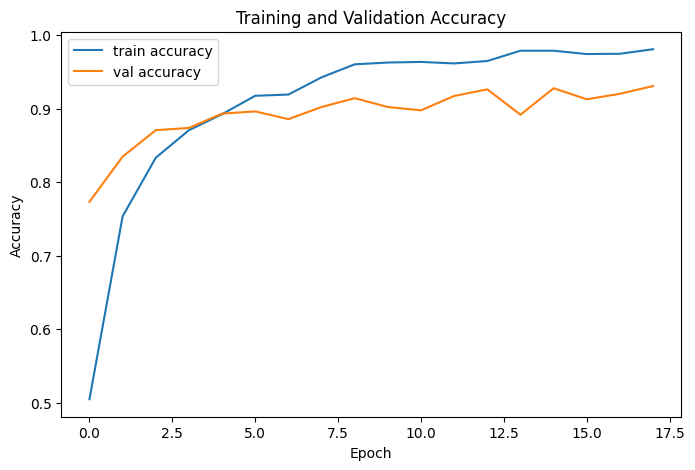

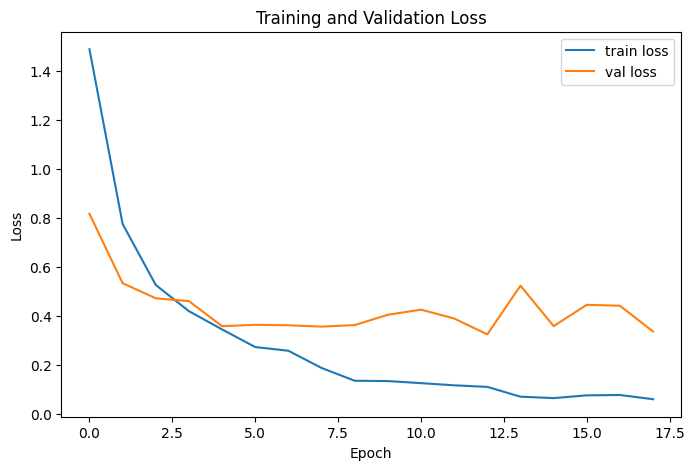

In [10]:
plot_history(history)

In [11]:
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
cm = confusion_matrix(y_true, y_pred)

11/11 [==============================] - 1s 19ms/step


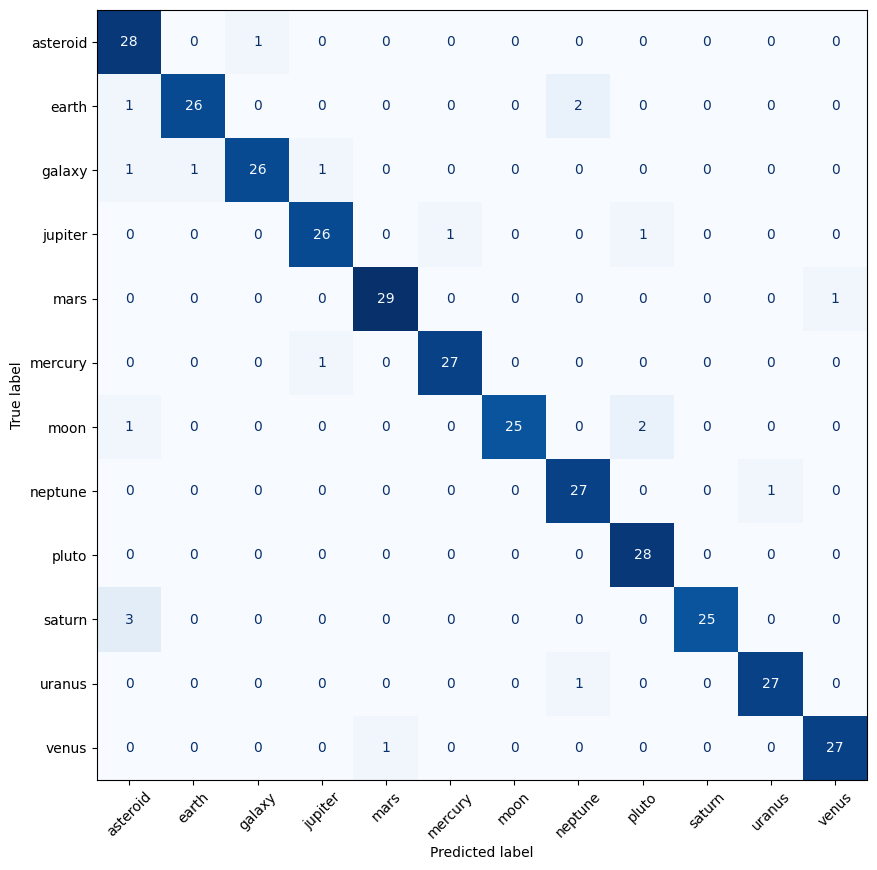

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.show()